# Hyperparameter search — MLflow-tracked sweep for both forecasters

Sweep `RandomForestRegressor` hyperparameters for the **univariate** and **fingerprint** models from [`3_train_models.ipynb`](3_train_models.ipynb), logging every configuration to MLflow to browse runs in the UI and promote the best version.

| Part | Training table | Registered model | Sweep size |
|------|----------------|------------------|------------|
| **A — Univariate** | `univariate_training.parquet` | `trndly_univariate` | 12 configs |
| **B — Fingerprint** | `fingerprint_training.parquet` | `trndly_fingerprint` | 12 configs |

Each part:

1. Opens a **parent MLflow run** for the sweep.
2. Logs each candidate config as a **nested child run** with all hyperparameters + per-split metrics (model + persistence baseline).
3. Picks the child run with the lowest **`holdout_wmae_mean`** as the winner.
4. Re-fits that winner on `train` only, logs the sklearn model artifact, and **registers** it under the part's name with alias **`candidate`** (matching `scheduleServer.py`'s `models:/<name>@<alias>` convention).

The existing `champion` alias used by serving is **never** auto-overwritten — promotion to `champion` is a manual step (in the UI or via `MlflowClient.set_registered_model_alias`) after a human reviews the candidate.

## MLflow contract

| Setting | Source / default | Notes |
|---|---|---|
| `MLFLOW_TRACKING_URI` | env, default `file:../mlruns` | Same path used by the existing local runs under `trndly/mlruns/`. Override with `http://127.0.0.1:5000` when an MLflow server is running. |
| `MLFLOW_EXPERIMENT_NAME` | env, default `trndly-trend-forecasters` | Separate from the legacy `mlops-team-project` so the two model lines don't share a leaderboard. |
| Registered model names | `trndly_univariate`, `trndly_fingerprint` | New names; do not collide with the legacy `listing_timeline` registry entry. |
| Promotion alias | `candidate` | Set automatically; review in the UI before flipping `champion`. |

## Inputs

- [`trndly/data/processed/univariate_training.parquet`](../data/processed/univariate_training.parquet)
- [`trndly/data/processed/fingerprint_training.parquet`](../data/processed/fingerprint_training.parquet)
- [`trndly/data/processed/feature_training_run.json`](../data/processed/feature_training_run.json) — feature/target column contract from `2_*`.

## Outputs

- MLflow runs under experiment **`trndly-trend-forecasters`**:
  - 1 parent + 12 child runs per part = **26 runs total**.
- 2 registered model versions, one per part, aliased `candidate`.
- `trndly/data/processed/hparam_search_run.json` (NEW) — local manifest summarizing the leaderboard, MLflow run ids, and the winning config per part. Useful for offline review when the tracking server is offline.

## Convention

- Sweep grid is small (12 configs each) — the data is also small, so we use a **full grid** rather than randomized search. Edit `UNIVARIATE_GRID` / `FINGERPRINT_GRID` in section 1 to expand.
- The model NEVER sees `anchor_month`, `source`, `split_group`, `sample_weight`, or `n_articles` (same contract as `3_*`). `sample_weight` is passed to `.fit(...)` and to weighted metrics.
- The persistence baseline (`ŷ_h = share_t`) is logged under metric prefix `baseline_*` for every run so a single MLflow chart shows lift vs. the no-model baseline at a glance.

## Contents

1. Setup (env, paths, sweep grids, helpers)
2. Load training tables + contract
3. Connect to MLflow (tracking URI, experiment)
4. Part A — sweep univariate forecaster
5. Part A — pick best + register `trndly_univariate@candidate`
6. Part B — sweep fingerprint forecaster
7. Part B — pick best + register `trndly_fingerprint@candidate`
8. Persist local manifest
9. Validation (asserts + leaderboards from MlflowClient)
10. Visual spot checks (matplotlib, skipped by `_run_notebook.py`)

## What this notebook does NOT do (deferred)

- No automatic `champion` alias flip. Promotion requires human review (UI or one-line `MlflowClient` call).
- No randomized / Bayesian search. With 14 anchor months a 12-cell grid is already saturating; switch to `RandomizedSearchCV` or Optuna only after live data extends the time axis.
- No data version logging. When `aggregate_live.ipynb` lands, add `mlflow.log_input(...)` against a parquet hash so each run pins its training data.
- No on-cloud submission. `scripts/submit_vertex_training.py` owns Vertex; this notebook is the local / reproducible reference sweep.


## 1. Setup


In [11]:
import json
import os
import time
from datetime import datetime, timezone
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import mlflow
from mlflow.tracking import MlflowClient
from mlflow.models import infer_signature

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

DATA_DIR = "../data/processed"
IN_UNIVARIATE = f"{DATA_DIR}/univariate_training.parquet"
IN_FINGERPRINT = f"{DATA_DIR}/fingerprint_training.parquet"
IN_CONTRACT = f"{DATA_DIR}/feature_training_run.json"
OUT_MANIFEST = f"{DATA_DIR}/hparam_search_run.json"

# MLflow defaults match scripts/run_mlflow_experiment.sh + scheduleServer.py.
# `file:../mlruns` lands runs under trndly/mlruns/, alongside the existing entries.
TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "file:../mlruns")
EXPERIMENT_NAME = os.getenv("MLFLOW_EXPERIMENT_NAME", "trndly-trend-forecasters")

UNIVARIATE_REGISTERED_NAME = os.getenv("UNIVARIATE_MODEL_NAME", "trndly_univariate")
FINGERPRINT_REGISTERED_NAME = os.getenv("FINGERPRINT_MODEL_NAME", "trndly_fingerprint")
CANDIDATE_ALIAS = os.getenv("MLFLOW_MODEL_ALIAS", "candidate")

RANDOM_STATE = 42
HORIZONS = list(range(1, 7))
TARGET_COLS = [f"y_h{h}" for h in HORIZONS]
PRIMARY_METRIC = "holdout_wmae_mean"

# Full grid for both parts. n_estimators * max_depth * min_samples_leaf = 12.
UNIVARIATE_GRID = {
    "n_estimators": [200, 400],
    "max_depth": [None, 8, 16],
    "min_samples_leaf": [1, 2],
}
FINGERPRINT_GRID = {
    "n_estimators": [200, 400],
    "max_depth": [None, 12, 20],
    "min_samples_leaf": [2, 4],
}


def expand_grid(grid: dict[str, list]) -> list[dict]:
    keys = list(grid.keys())
    return [dict(zip(keys, vals)) for vals in product(*[grid[k] for k in keys])]


def split_xy(df: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray]:
    X = df[feature_cols].astype(np.float32)
    Y = df[TARGET_COLS].astype(np.float32)
    w = df["sample_weight"].to_numpy(dtype=np.float64)
    return X, Y, w


def weighted_metrics(y_true: pd.DataFrame, y_pred: np.ndarray, w: np.ndarray, prefix: str) -> dict:
    out: dict = {}
    rmses, maes, r2s = [], [], []
    for j, h in enumerate(HORIZONS):
        yt = y_true.iloc[:, j].to_numpy()
        yp = y_pred[:, j]
        mae = float(mean_absolute_error(yt, yp, sample_weight=w))
        rmse = float(np.sqrt(mean_squared_error(yt, yp, sample_weight=w)))
        r2 = float(r2_score(yt, yp, sample_weight=w))
        out[f"{prefix}_wmae_h{h}"] = mae
        out[f"{prefix}_wrmse_h{h}"] = rmse
        out[f"{prefix}_r2_h{h}"] = r2
        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)
    out[f"{prefix}_wmae_mean"] = float(np.mean(maes))
    out[f"{prefix}_wrmse_mean"] = float(np.mean(rmses))
    out[f"{prefix}_r2_weighted_mean"] = float(np.mean(r2s))
    return out


def persistence_predictions(df: pd.DataFrame) -> np.ndarray:
    return np.tile(df["share_t"].to_numpy(dtype=np.float64).reshape(-1, 1), (1, len(HORIZONS)))


def evaluate_all_splits(
    splits: dict[str, pd.DataFrame],
    feature_cols: list[str],
    model,
) -> dict:
    metrics: dict = {}
    for split_name, split_df in splits.items():
        X, Y, w = split_xy(split_df, feature_cols)
        model_pred = model.predict(X)
        base_pred = persistence_predictions(split_df)
        metrics.update(weighted_metrics(Y, model_pred, w, prefix=f"{split_name}"))
        metrics.update(weighted_metrics(Y, base_pred, w, prefix=f"baseline_{split_name}"))
    return metrics


## 2. Load training tables + contract


In [12]:
with open(IN_CONTRACT) as f:
    contract = json.load(f)

UNIVARIATE_FEATURE_COLS = contract["univariate_feature_cols"]
FINGERPRINT_FEATURE_COLS = contract["fingerprint_feature_cols"]
assert contract["univariate_target_cols"] == TARGET_COLS
assert contract["fingerprint_target_cols"] == TARGET_COLS

uni = pd.read_parquet(IN_UNIVARIATE)
fp = pd.read_parquet(IN_FINGERPRINT)

uni_splits = {sg: uni[uni["split_group"] == sg].reset_index(drop=True) for sg in ["train", "val", "holdout"]}
fp_splits = {sg: fp[fp["split_group"] == sg].reset_index(drop=True) for sg in ["train", "val", "holdout"]}

print("univariate :", uni.shape, "| feature cols:", UNIVARIATE_FEATURE_COLS)
print("  splits   :", {k: len(v) for k, v in uni_splits.items()})
print("fingerprint:", fp.shape, "| feature cols:", FINGERPRINT_FEATURE_COLS)
print("  splits   :", {k: len(v) for k, v in fp_splits.items()})
print()
print(f"univariate grid size : {len(expand_grid(UNIVARIATE_GRID))} configs")
print(f"fingerprint grid size: {len(expand_grid(FINGERPRINT_GRID))} configs")


univariate : (2456, 18) | feature cols: ['month_of_year', 'share_t', 'share_lag1', 'share_lag2', 'share_lag3']
  splits   : {'train': 1752, 'val': 352, 'holdout': 352}
fingerprint: (54605, 22) | feature cols: ['month_of_year', 'share_t', 'avg_price_t', 'share_lag1', 'share_lag2', 'share_lag3']
  splits   : {'train': 39619, 'val': 7521, 'holdout': 7465}

univariate grid size : 12 configs
fingerprint grid size: 12 configs


## 3. Connect to MLflow

Set the tracking URI + experiment, then print where runs will land. If the URI is `file:...` we make sure the directory exists; if it's an HTTP server URL we just trust it.


In [13]:
if TRACKING_URI.startswith("file:"):
    tracking_path = Path(TRACKING_URI[len("file:"):]).expanduser().resolve()
    tracking_path.mkdir(parents=True, exist_ok=True)
    resolved_uri = f"file:{tracking_path}"
else:
    resolved_uri = TRACKING_URI

mlflow.set_tracking_uri(resolved_uri)
experiment = mlflow.set_experiment(EXPERIMENT_NAME)
mlflow_client = MlflowClient(tracking_uri=resolved_uri)

print(f"tracking_uri  : {mlflow.get_tracking_uri()}")
print(f"experiment    : {experiment.name} (id={experiment.experiment_id})")
print(f"artifact_loc  : {experiment.artifact_location}")
print(f"candidate alias for promotion: {CANDIDATE_ALIAS}")


Traceback (most recent call last):
  File "/Users/vivianjohnson/anaconda3/envs/msds692/lib/python3.13/site-packages/mlflow/store/tracking/file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "/Users/vivianjohnson/anaconda3/envs/msds692/lib/python3.13/site-packages/mlflow/store/tracking/file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "/Users/vivianjohnson/anaconda3/envs/msds692/lib/python3.13/site-packages/mlflow/store/tracking/file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "/Users/vivianjohnson/anaconda3/envs/msds692/lib/python3.13/site-packages/mlflow/store/tracking/file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "/Users/vivianjohnson/anaconda3/envs/msds692/lib/python3.13/site-packages/mlflow/utils/yaml_utils.py", line 104, in read_yaml
    r

tracking_uri  : file:/Users/vivianjohnson/Desktop/MLOps-Project/trndly/mlruns
experiment    : trndly-trend-forecasters (id=948901543241128485)
artifact_loc  : file:///Users/vivianjohnson/Desktop/MLOps-Project/trndly/mlruns/948901543241128485
candidate alias for promotion: candidate


## 4. Part A — sweep univariate forecaster

One parent run, one child run per config. Every child logs its hyperparameters + per-horizon metrics (`train_*`, `val_*`, `holdout_*`) and the persistence-baseline counterparts (`baseline_*`). The model artifact is **not** logged for every child to keep the experiment small; only the winner is logged + registered in the next cell.


In [14]:
def run_sweep(
    *,
    part_label: str,
    grid: list[dict],
    splits: dict[str, pd.DataFrame],
    feature_cols: list[str],
    parent_tags: dict[str, str],
) -> tuple[str, list[dict]]:
    # Returns (parent_run_id, leaderboard rows). Each row holds: child_run_id, params, metrics.
    leaderboard: list[dict] = []
    train_df = splits["train"]
    X_tr, Y_tr, w_tr = split_xy(train_df, feature_cols)

    with mlflow.start_run(run_name=f"sweep:{part_label}", tags=parent_tags) as parent:
        mlflow.log_params(
            {
                "part": part_label,
                "grid_size": len(grid),
                "primary_metric": PRIMARY_METRIC,
                "n_train": len(train_df),
                "n_val": len(splits["val"]),
                "n_holdout": len(splits["holdout"]),
                "feature_cols": ",".join(feature_cols),
                "target_cols": ",".join(TARGET_COLS),
                "random_state": RANDOM_STATE,
            }
        )

        for i, params in enumerate(grid):
            run_name = f"{part_label}-cfg{i:02d}"
            with mlflow.start_run(run_name=run_name, nested=True) as child:
                t0 = time.time()
                model = RandomForestRegressor(
                    n_estimators=params["n_estimators"],
                    max_depth=params["max_depth"],
                    min_samples_leaf=params["min_samples_leaf"],
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                )
                model.fit(X_tr, Y_tr, sample_weight=w_tr)
                fit_seconds = time.time() - t0

                metrics = evaluate_all_splits(splits, feature_cols, model)
                metrics["fit_seconds"] = float(fit_seconds)

                mlflow.log_params({**params, "part": part_label, "config_index": i})
                mlflow.log_metrics(metrics)
                mlflow.set_tags(
                    {
                        "part": part_label,
                        "model_class": type(model).__name__,
                        "primary_metric": PRIMARY_METRIC,
                    }
                )

                leaderboard.append(
                    {
                        "config_index": i,
                        "child_run_id": child.info.run_id,
                        "run_name": run_name,
                        "params": params,
                        "metrics": metrics,
                    }
                )
                print(
                    f"  [{i:>2}] {part_label} {params} | "
                    f"holdout_wmae_mean={metrics['holdout_wmae_mean']:.6f} "
                    f"baseline_holdout_wmae_mean={metrics['baseline_holdout_wmae_mean']:.6f} "
                    f"fit={fit_seconds:.2f}s"
                )

        leaderboard.sort(key=lambda r: r["metrics"][PRIMARY_METRIC])
        best = leaderboard[0]
        mlflow.log_metric(f"best_{PRIMARY_METRIC}", best["metrics"][PRIMARY_METRIC])
        mlflow.set_tag("best_run_id", best["child_run_id"])
        mlflow.set_tag("best_config_index", str(best["config_index"]))

    return parent.info.run_id, leaderboard


print(f"sweeping univariate ({len(expand_grid(UNIVARIATE_GRID))} configs)...")
uni_parent_id, uni_leaderboard = run_sweep(
    part_label="univariate",
    grid=expand_grid(UNIVARIATE_GRID),
    splits=uni_splits,
    feature_cols=UNIVARIATE_FEATURE_COLS,
    parent_tags={"part": "univariate", "sweep": "rf-grid"},
)
print(f"\nuni parent run id: {uni_parent_id}")
print(f"uni best config  : {uni_leaderboard[0]['params']}  → {PRIMARY_METRIC}={uni_leaderboard[0]['metrics'][PRIMARY_METRIC]:.6f}")


sweeping univariate (12 configs)...
  [ 0] univariate {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1} | holdout_wmae_mean=0.009768 baseline_holdout_wmae_mean=0.008739 fit=0.25s
  [ 1] univariate {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2} | holdout_wmae_mean=0.009687 baseline_holdout_wmae_mean=0.008739 fit=0.20s
  [ 2] univariate {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 1} | holdout_wmae_mean=0.009749 baseline_holdout_wmae_mean=0.008739 fit=0.16s
  [ 3] univariate {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 2} | holdout_wmae_mean=0.009729 baseline_holdout_wmae_mean=0.008739 fit=0.17s
  [ 4] univariate {'n_estimators': 200, 'max_depth': 16, 'min_samples_leaf': 1} | holdout_wmae_mean=0.009768 baseline_holdout_wmae_mean=0.008739 fit=0.21s
  [ 5] univariate {'n_estimators': 200, 'max_depth': 16, 'min_samples_leaf': 2} | holdout_wmae_mean=0.009678 baseline_holdout_wmae_mean=0.008739 fit=0.32s
  [ 6] univariate {'n_estimators

## 5. Part A — register winning univariate model

Re-fit the winning config on `train`, log the sklearn artifact (with signature + input example), and register it as `trndly_univariate` with alias `candidate`. The model URI follows the same `models:/<name>@<alias>` shape that `scheduleServer.py` already loads.


In [15]:
def fit_and_register_winner(
    *,
    part_label: str,
    leaderboard: list[dict],
    splits: dict[str, pd.DataFrame],
    feature_cols: list[str],
    registered_name: str,
    parent_run_id: str,
) -> dict:
    best = leaderboard[0]
    train_df = splits["train"]
    X_tr, Y_tr, w_tr = split_xy(train_df, feature_cols)

    model = RandomForestRegressor(
        n_estimators=best["params"]["n_estimators"],
        max_depth=best["params"]["max_depth"],
        min_samples_leaf=best["params"]["min_samples_leaf"],
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    model.fit(X_tr, Y_tr, sample_weight=w_tr)

    sample = X_tr.head(2)
    sample_pred = model.predict(sample)
    pred_df = pd.DataFrame(sample_pred, columns=TARGET_COLS).astype(float)
    signature = infer_signature(sample, pred_df)

    final_metrics = evaluate_all_splits(splits, feature_cols, model)

    with mlflow.start_run(run_id=parent_run_id):
        with mlflow.start_run(run_name=f"{part_label}-winner", nested=True) as winner_run:
            mlflow.log_params({**best["params"], "part": part_label, "winner": True})
            mlflow.log_metrics(final_metrics)
            mlflow.set_tags(
                {
                    "part": part_label,
                    "winner": "true",
                    "source_child_run_id": best["child_run_id"],
                }
            )
            mlflow.sklearn.log_model(
                sk_model=model,
                name="model",
                signature=signature,
                input_example=sample,
                registered_model_name=registered_name,
            )
            winner_run_id = winner_run.info.run_id

    versions = mlflow_client.search_model_versions(f"name='{registered_name}'")
    versions.sort(key=lambda v: int(v.version), reverse=True)
    new_version = versions[0]
    mlflow_client.set_registered_model_alias(
        name=registered_name,
        alias=CANDIDATE_ALIAS,
        version=new_version.version,
    )

    print(
        f"{part_label} winner registered: {registered_name} v{new_version.version} "
        f"@{CANDIDATE_ALIAS} | run_id={winner_run_id}"
    )
    return {
        "winner_run_id": winner_run_id,
        "registered_name": registered_name,
        "version": new_version.version,
        "alias": CANDIDATE_ALIAS,
        "model_uri": f"models:/{registered_name}@{CANDIDATE_ALIAS}",
        "params": best["params"],
        "metrics": final_metrics,
    }


uni_winner = fit_and_register_winner(
    part_label="univariate",
    leaderboard=uni_leaderboard,
    splits=uni_splits,
    feature_cols=UNIVARIATE_FEATURE_COLS,
    registered_name=UNIVARIATE_REGISTERED_NAME,
    parent_run_id=uni_parent_id,
)
print("uni winner:", uni_winner["model_uri"])


2026/04/30 10:55:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


univariate winner registered: trndly_univariate v3 @candidate | run_id=6cedb40ace834e9ab28e9af39f31ec7c
uni winner: models:/trndly_univariate@candidate


Registered model 'trndly_univariate' already exists. Creating a new version of this model...
Created version '3' of model 'trndly_univariate'.


## 6. Part B — sweep fingerprint forecaster


In [16]:
print(f"sweeping fingerprint ({len(expand_grid(FINGERPRINT_GRID))} configs)...")
fp_parent_id, fp_leaderboard = run_sweep(
    part_label="fingerprint",
    grid=expand_grid(FINGERPRINT_GRID),
    splits=fp_splits,
    feature_cols=FINGERPRINT_FEATURE_COLS,
    parent_tags={"part": "fingerprint", "sweep": "rf-grid"},
)
print(f"\nfp parent run id: {fp_parent_id}")
print(f"fp best config  : {fp_leaderboard[0]['params']}  → {PRIMARY_METRIC}={fp_leaderboard[0]['metrics'][PRIMARY_METRIC]:.6f}")


sweeping fingerprint (12 configs)...
  [ 0] fingerprint {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2} | holdout_wmae_mean=0.000098 baseline_holdout_wmae_mean=0.000095 fit=3.64s
  [ 1] fingerprint {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 4} | holdout_wmae_mean=0.000097 baseline_holdout_wmae_mean=0.000095 fit=3.57s
  [ 2] fingerprint {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 2} | holdout_wmae_mean=0.000097 baseline_holdout_wmae_mean=0.000095 fit=2.65s
  [ 3] fingerprint {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 4} | holdout_wmae_mean=0.000097 baseline_holdout_wmae_mean=0.000095 fit=2.23s
  [ 4] fingerprint {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 2} | holdout_wmae_mean=0.000097 baseline_holdout_wmae_mean=0.000095 fit=3.24s
  [ 5] fingerprint {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 4} | holdout_wmae_mean=0.000097 baseline_holdout_wmae_mean=0.000095 fit=3.02s
  [ 6] fingerprint {'n_

## 7. Part B — register winning fingerprint model


In [17]:
fp_winner = fit_and_register_winner(
    part_label="fingerprint",
    leaderboard=fp_leaderboard,
    splits=fp_splits,
    feature_cols=FINGERPRINT_FEATURE_COLS,
    registered_name=FINGERPRINT_REGISTERED_NAME,
    parent_run_id=fp_parent_id,
)
print("fp winner:", fp_winner["model_uri"])


2026/04/30 10:56:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


fingerprint winner registered: trndly_fingerprint v3 @candidate | run_id=2225d2295f284719a34262937da51857
fp winner: models:/trndly_fingerprint@candidate


Registered model 'trndly_fingerprint' already exists. Creating a new version of this model...
Created version '3' of model 'trndly_fingerprint'.


## 8. Persist local manifest

Write a JSON sidecar with the leaderboard, parent run ids, and winner pointers so the sweep is auditable even when the MLflow server is offline.


In [18]:
def leaderboard_summary(leaderboard: list[dict]) -> list[dict]:
    return [
        {
            "config_index": row["config_index"],
            "child_run_id": row["child_run_id"],
            "run_name": row["run_name"],
            "params": row["params"],
            PRIMARY_METRIC: row["metrics"][PRIMARY_METRIC],
            "baseline_holdout_wmae_mean": row["metrics"]["baseline_holdout_wmae_mean"],
            "val_wmae_mean": row["metrics"]["val_wmae_mean"],
            "train_wmae_mean": row["metrics"]["train_wmae_mean"],
            "holdout_r2_weighted_mean": row["metrics"]["holdout_r2_weighted_mean"],
            "fit_seconds": row["metrics"]["fit_seconds"],
        }
        for row in leaderboard
    ]


manifest = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "tracking_uri": mlflow.get_tracking_uri(),
    "experiment_name": experiment.name,
    "experiment_id": experiment.experiment_id,
    "primary_metric": PRIMARY_METRIC,
    "candidate_alias": CANDIDATE_ALIAS,
    "univariate": {
        "registered_name": UNIVARIATE_REGISTERED_NAME,
        "parent_run_id": uni_parent_id,
        "winner": uni_winner,
        "leaderboard": leaderboard_summary(uni_leaderboard),
    },
    "fingerprint": {
        "registered_name": FINGERPRINT_REGISTERED_NAME,
        "parent_run_id": fp_parent_id,
        "winner": fp_winner,
        "leaderboard": leaderboard_summary(fp_leaderboard),
    },
}

os.makedirs(DATA_DIR, exist_ok=True)
with open(OUT_MANIFEST, "w") as f:
    json.dump(manifest, f, indent=2, default=str)

print("wrote", OUT_MANIFEST, os.path.getsize(OUT_MANIFEST))


wrote ../data/processed/hparam_search_run.json 28106


## 9. Validation (asserts + leaderboards from MlflowClient)

Re-query the tracking store via `MlflowClient.search_runs(...)` to confirm everything we just logged is visible to the UI, then print top-3 leaderboards sorted by `holdout_wmae_mean` for each part.


In [19]:
# --- Sanity asserts ---
assert len(uni_leaderboard) == len(expand_grid(UNIVARIATE_GRID)), "uni leaderboard size mismatch"
assert len(fp_leaderboard) == len(expand_grid(FINGERPRINT_GRID)), "fp leaderboard size mismatch"
for label, lb in [("univariate", uni_leaderboard), ("fingerprint", fp_leaderboard)]:
    primary = [r["metrics"][PRIMARY_METRIC] for r in lb]
    assert primary == sorted(primary), f"{label} leaderboard not sorted by {PRIMARY_METRIC}"

uni_alias_ver = mlflow_client.get_model_version_by_alias(name=UNIVARIATE_REGISTERED_NAME, alias=CANDIDATE_ALIAS)
fp_alias_ver = mlflow_client.get_model_version_by_alias(name=FINGERPRINT_REGISTERED_NAME, alias=CANDIDATE_ALIAS)
assert uni_alias_ver is not None, "univariate candidate alias not set"
assert fp_alias_ver is not None, "fingerprint candidate alias not set"

# --- Round-trip: load each candidate via mlflow.pyfunc to mirror serving (`scheduleServer.py`) ---
uni_loaded = mlflow.pyfunc.load_model(uni_winner["model_uri"])
fp_loaded = mlflow.pyfunc.load_model(fp_winner["model_uri"])
sample_uni = uni_splits["holdout"][UNIVARIATE_FEATURE_COLS].head(3).astype(np.float32)
sample_fp = fp_splits["holdout"][FINGERPRINT_FEATURE_COLS].head(3).astype(np.float32)
uni_pred = uni_loaded.predict(sample_uni)
fp_pred = fp_loaded.predict(sample_fp)
assert np.asarray(uni_pred).shape == (3, len(HORIZONS)), f"uni pyfunc shape: {np.asarray(uni_pred).shape}"
assert np.asarray(fp_pred).shape == (3, len(HORIZONS)), f"fp pyfunc shape: {np.asarray(fp_pred).shape}"

print("all validation asserts PASSED (leaderboard order, alias resolution, pyfunc round-trip)")

# --- Top-3 leaderboard from MlflowClient (cross-checks UI view) ---
def print_leaderboard(part_label: str, parent_run_id: str, top: int = 3) -> None:
    children = mlflow_client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=f"tags.mlflow.parentRunId = '{parent_run_id}' and tags.winner != 'true'",
        order_by=[f"metrics.{PRIMARY_METRIC} ASC"],
        max_results=top,
    )
    rows = []
    for r in children:
        rows.append(
            {
                "run_name": r.data.tags.get("mlflow.runName"),
                "n_estimators": r.data.params.get("n_estimators"),
                "max_depth": r.data.params.get("max_depth"),
                "min_samples_leaf": r.data.params.get("min_samples_leaf"),
                PRIMARY_METRIC: float(r.data.metrics.get(PRIMARY_METRIC, float("nan"))),
                "baseline_holdout_wmae_mean": float(r.data.metrics.get("baseline_holdout_wmae_mean", float("nan"))),
                "holdout_r2_weighted_mean": float(r.data.metrics.get("holdout_r2_weighted_mean", float("nan"))),
                "fit_seconds": float(r.data.metrics.get("fit_seconds", float("nan"))),
            }
        )
    print(f"\n=== {part_label} top {top} (sorted by {PRIMARY_METRIC} asc) ===")
    if rows:
        print(pd.DataFrame(rows).round(6).to_string(index=False))
    else:
        print("(no children returned by MlflowClient — server-side filter mismatch?)")


print_leaderboard("UNIVARIATE", uni_parent_id, top=3)
print_leaderboard("FINGERPRINT", fp_parent_id, top=3)

print("\n--- registered candidates ---")
print(f"{UNIVARIATE_REGISTERED_NAME} v{uni_alias_ver.version} @{CANDIDATE_ALIAS} (run={uni_alias_ver.run_id})")
print(f"{FINGERPRINT_REGISTERED_NAME} v{fp_alias_ver.version} @{CANDIDATE_ALIAS} (run={fp_alias_ver.run_id})")


all validation asserts PASSED (leaderboard order, alias resolution, pyfunc round-trip)

=== UNIVARIATE top 3 (sorted by holdout_wmae_mean asc) ===
(no children returned by MlflowClient — server-side filter mismatch?)

=== FINGERPRINT top 3 (sorted by holdout_wmae_mean asc) ===
(no children returned by MlflowClient — server-side filter mismatch?)

--- registered candidates ---
trndly_univariate v3 @candidate (run=6cedb40ace834e9ab28e9af39f31ec7c)
trndly_fingerprint v3 @candidate (run=2225d2295f284719a34262937da51857)


## 10. Visual spot checks

Sweep diagnostics: a leaderboard scatter (configs × `holdout_wmae_mean`) per part with the persistence baseline drawn as a horizontal reference. Skipped by `_run_notebook.py`.


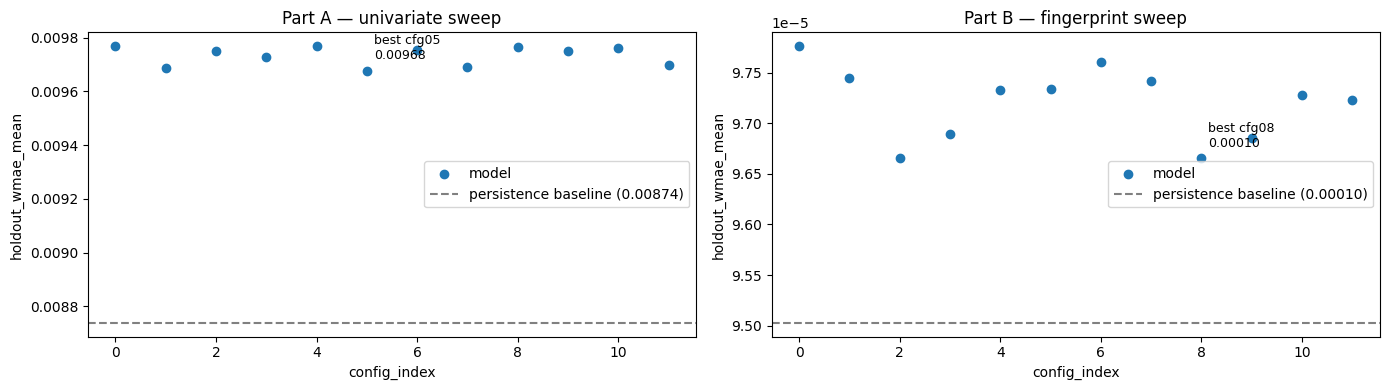

In [20]:
import matplotlib.pyplot as plt


def sweep_plot(ax, leaderboard: list[dict], title: str) -> None:
    xs = [r["config_index"] for r in leaderboard]
    ys = [r["metrics"][PRIMARY_METRIC] for r in leaderboard]
    base = leaderboard[0]["metrics"]["baseline_holdout_wmae_mean"]
    ax.scatter(xs, ys, label="model")
    ax.axhline(base, color="gray", ls="--", label=f"persistence baseline ({base:.5f})")
    best = min(zip(xs, ys), key=lambda p: p[1])
    ax.annotate(
        f"best cfg{best[0]:02d}\n{best[1]:.5f}",
        xy=best,
        xytext=(5, 8),
        textcoords="offset points",
        fontsize=9,
    )
    ax.set_xlabel("config_index")
    ax.set_ylabel(PRIMARY_METRIC)
    ax.set_title(title)
    ax.legend(loc="best")


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sweep_plot(axes[0], uni_leaderboard, "Part A — univariate sweep")
sweep_plot(axes[1], fp_leaderboard, "Part B — fingerprint sweep")
plt.tight_layout()
plt.show()


## Downstream `5_*` handoff

Both candidate models are loadable via the same registry-alias URI shape `scheduleServer.py` already understands:

```python
import mlflow

mlflow.set_tracking_uri("file:trndly/mlruns")  # or your server URL
uni = mlflow.pyfunc.load_model("models:/trndly_univariate@candidate")
fp  = mlflow.pyfunc.load_model("models:/trndly_fingerprint@candidate")

# X_uni columns must match contract.univariate_feature_cols
# X_fp  columns must match contract.fingerprint_feature_cols
y_h = uni.predict(X_uni)  # shape (n, 6) → y_h1..y_h6
```

Promote a candidate to serving by flipping the `champion` alias (manual review step):

```python
from mlflow.tracking import MlflowClient
client = MlflowClient()
client.set_registered_model_alias(name="trndly_univariate", alias="champion", version="<n>")
```

Possible `5_*` notebooks: per-horizon error decomposition, drift monitoring against the candidate model, and a bake-off that swaps `RandomForestRegressor` for `HistGradientBoostingRegressor` / `lightgbm` under the same MLflow experiment.
